<a href="https://colab.research.google.com/github/poojithapalagani/Customer_Purchase_Prediction_ANN/blob/main/Pro2_ImageClassification_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step1 - Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [ ]:
# Step2 - Load Dataset (Fashion - MNIST)
from tensorflow.keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


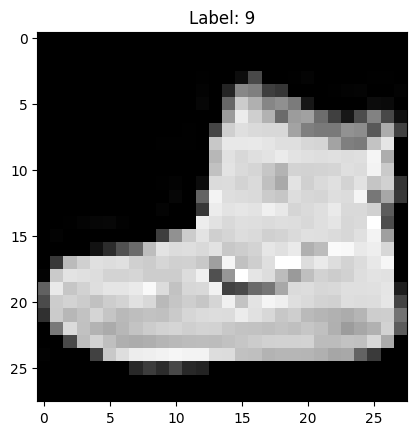

In [ ]:
# Step3 - Visualize Images
plt.imshow(X_train[0], cmap='gray')
plt.title("Label: " + str(y_train[0]))
plt.show()

In [ ]:
# Step4 - Normalize pixel Values
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
# check the ouptu
X_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [ ]:
# step5 - Reshape Data
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [ ]:
# stpe6 - Train/validation split
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42
)

In [ ]:
# check shapes
print("Train:", X_train.shape)
print("Validation:", X_val.shape)

Train: (48000, 28, 28, 1)
Validation: (12000, 28, 28, 1)


In [ ]:
# step7 - Data Augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

In [ ]:
datagen.fit(X_train)

In [ ]:
# step8 - Build CNN Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

model = Sequential([
    Input(shape=(28,28,1)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

In [ ]:
# step9 - Compile & Train CNN
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=10,
    validation_data=(X_val, y_val)
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 40s 25ms/step - accuracy: 0.6948 - loss: 0.8151 - val_accuracy: 0.8114 - val_loss: 0.5041
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 36s 24ms/step - accuracy: 0.7736 - loss: 0.6005 - val_accuracy: 0.8353 - val_loss: 0.4387
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - accuracy: 0.8006 - loss: 0.5339 - val_accuracy: 0.8513 - val_loss: 0.3932
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - accuracy: 0.8172 - loss: 0.4925 - val_accuracy: 0.8660 - val_loss: 0.3528
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 36s 24ms/step - accuracy: 0.8279 - loss: 0.4596 - val_accuracy: 0.8753 - val_loss: 0.3357
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 36s 24ms/step - accuracy: 0.8386 - loss: 0.4395 - val_accuracy: 0.8687 - val_loss: 0.3439
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 35s 24ms/step - accuracy: 0.8435 - loss: 0.4219 - val_accuracy: 0.8816 - val_loss: 0.3188
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.8481 -

In [ ]:
# step10.1 - Model Evaluation
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8783 - loss: 0.3216
Test Accuracy: 0.8783000111579895


In [ ]:
# step10.2 - Predictions
y_pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [ ]:
# step10.3 - Convert Predictions
import numpy as np
y_pred_classes = np.argmax(y_pred, axis=1)

In [ ]:
# step11.1 - Create Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_classes)
print(cm)

[[832   0  10  11   5   1 132   0   9   0]
 [  0 972   1  14   4   0   6   0   3   0]
 [  9   0 781   4  43   0 161   0   2   0]
 [ 22   6   8 863  32   0  60   0   7   2]
 [  0   1  82  27 741   0 148   0   1   0]
 [  0   0   0   0   0 975   0  19   4   2]
 [137   1  52  19  68   0 708   0  15   0]
 [  0   0   0   0   0  12   0 973   0  15]
 [  1   0   2   2   3   1   2   3 986   0]
 [  0   0   0   0   0   7   0  39   2 952]]


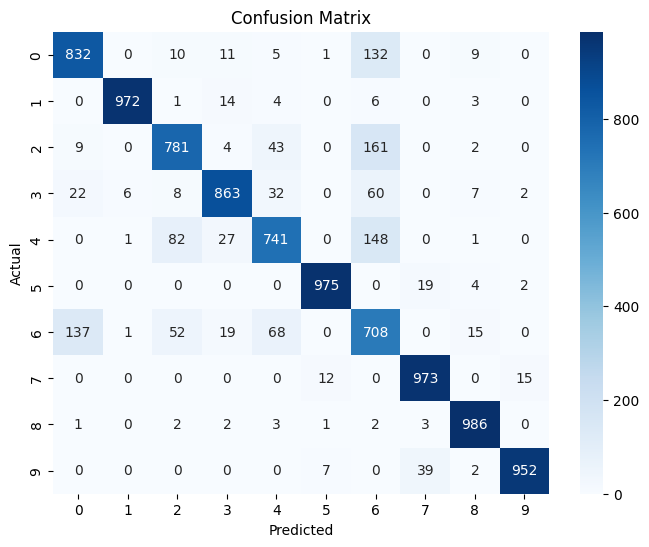

In [ ]:
# step 11.2 - visualzie
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()